In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import glob, os

def reshape_long(df):
    cols = set([c.split(' ')[0] for c in df])
    rows = set([int(c.split(' ')[1]) for c in df])
    
    def get_slice(r):
        df_slice = df[[f'{c} {r}' for c in cols]].copy()
        df_slice.columns = cols
        return df_slice
    
    return pd.concat([
        get_slice(r)
        for r in rows
    ], axis=0, keys=rows)

def load_all(pattern):
    files = list(glob.glob('./output_cameo/control_solution_*.csv'))

    return pd.concat(
        [
            reshape_long(pd.read_csv(f))
            for f in files
        ],
        keys=[os.path.splitext(os.path.basename(s))[0] for s in files],
        names=['config', 'sim', 'time']
    )
    
df_all = load_all('./output_cameo/control_solution_*.csv')
df_all

SoC        kW   kB
config                                  sim time                          
control_solution_c4_p1000_LFP_MOSSLAND  22  0     89.639999  0.311746  3.0
                                            1     89.639999  0.311746  3.0
                                            2     89.640000  0.311746  3.0
                                            3     89.640001  0.311746  3.0
                                            4     89.640002  0.209863  3.0
...                                                     ...       ...  ...
control_solution_c2_p100_LAB_COTTONWOOD 121 91    90.137966  1.400238  3.0
                                            92    90.137967  1.472367  3.0
                                            93    90.137969  1.472367  3.0
                                            94    90.137970  1.472367  3.0
                                            95    90.137972  1.472367  3.0

[1536000 rows x 3 columns]

In [76]:
config = df_all.index.get_level_values('config').unique()

def parse_config(s, prefix='control_solution_'):
    a, b, c, d = s.removeprefix(prefix).split('_')
    return [
        int(a.removeprefix('c')),
        int(b.removeprefix('p')),
        c,
        d
    ]


df_config = pd.DataFrame(
    [
        parse_config(c)
        for c in config
    ],
    index=config,
    columns=['duration', 'power', 'technology', 'location']
)

df_summary = pd.read_csv('./v2_summary.csv')

cols = list(set(df_summary.columns).intersection(df_config.columns))

df_config = df_config.merge(df_summary, on=cols, how='left')\
    .set_index(df_config.index)

df_config

,duration,power,technology,location,capacity,cost,size,cable,objective
config,,,,,,,,,
control_solution_c4_p1000_LFP_MOSSLAND,4,1000,LFP,MOSSLAND,1800.0,1406.11,44.819999,1629.705002,2932.687641
control_solution_c8_p1000_VRF_COTTONWOOD,8,1000,VRF,COTTONWOOD,1810.0,3652.63,0.000006,1618.102297,3470.498010
control_solution_c2_p100_LAB_JOHNDAY,2,100,LAB,JOHNDAY,2350.0,957.58,58.514999,2127.670419,4792.285652
control_solution_c4_p100_LFP_WCASCADE,4,100,LFP,WCASCADE,1500.0,1490.89,37.349999,1358.087501,2692.958225
control_solution_c6_p1000_VRF_JOHNDAY,6,1000,VRF,JOHNDAY,2350.0,3248.67,0.000034,2100.851060,4748.688494
...,...,...,...,...,...,...,...,...,...
control_solution_c4_p1000_LFP_JOHNDAY,4,1000,LFP,JOHNDAY,2350.0,1406.11,58.514999,2127.670419,4784.660727
control_solution_c8_p100_NMC_TESLA,8,100,NMC,TESLA,2640.0,3141.71,1.186058,2360.648613,4995.617342
control_solution_c4_p100_LFP_COTTONWOOD,4,100,LFP,COTTONWOOD,1810.0,1490.89,45.068999,1638.758919,3494.801517


In [98]:
df_config.to_pickle('./v2_summary_with_control_config.pkl')

In [77]:
import matplotlib.pyplot as plt
from matplotlib.collections import EllipseCollection, LineCollection

import numpy as np

from sklearn.neighbors import BallTree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from umap import UMAP

RANDOM_SEED = 1234567890

def coreset_2d(xy, r=1.0):
    tree = BallTree(xy, metric='euclidean')
    density = tree.query_radius(xy, r, count_only=True)
    
    covered = set()
    centers = []
    
    # loop over points from highest density to lowest
    for i in np.argsort(density)[::-1]:
        if not i in covered:
            nei = tree.query_radius(xy[[i]], r)[0]
            if len(covered.intersection(nei)) == 0:
                centers.append(i)
                covered.update(nei)
    
    # assign every point to its closest center
    _, knn = BallTree(xy[centers], metric='euclidean')\
        .query(xy)

    centers = np.array(centers)

    # return both the coreset centers and assign each observation to a center
    return centers, centers[knn[:, 0]]
    
def takens_transformation(dfk, n=2):

    X = np.hstack([
        dfk.iloc[i:len(dfk) - n + i + 1].values
        for i in range(n)
    ])

    return pd.DataFrame(
        X,
        columns=[f'{c}_{i}' for i in range(n) for c in dfk]
    )

def get_limits(values):
    xmin, ymin = values.min()
    xmax, ymax = values.max()
    return [xmin, xmax], [ymin, ymax]

def zscore_normalize(df):
    return (df - df.mean())/df.std()
    
class TimeseriesGlyphVisualization:
    def __init__(self, df, normalize=None):
        self.df = df

        if normalize is not None:
            self.df = self.df.groupby(**normalize, group_keys=False, as_index=False)\
                .apply(zscore_normalize)
                
        self.df_takens = self.df.groupby(['config', 'sim'])\
            .apply(takens_transformation, n=3)
    
        self.df_takens_2d = pd.DataFrame(
            PCA(whiten=normalize is None, n_components=2, random_state=RANDOM_SEED).fit_transform(self.df_takens),
            index=self.df_takens.index
        )

        # compute limits of all glyphs (useful for drawing later)
        self.xlim, self.ylim = get_limits(self.df_takens_2d)
        

        # use 2d projected takens representation as features
        # option 2: use raw timeseries as features
        self.X = self.df_takens_2d.unstack()

        self.xy = Pipeline([
            # ('norm', StandardScaler()),
            ('proj', UMAP(random_state=RANDOM_SEED))
        ]).fit_transform(self.X)


    def select_glyphs_from_cluster(self, cluster, *args):
        return [
            self.X.index[ci == cluster]
            for ci in args
        ]
    
    def show_glyph_embedding(self, spacing='auto', cmap='Blues', glyph_size=1, clip_cmap=0.2, show_points=False, debug=False, show_labels=False):
        r = (1.0 if spacing == 'auto' else spacing)
            
        centers, knn = coreset_2d(self.xy, r)
        
        xmax, ymax = self.df_takens_2d.max()
        xmin, ymin = self.df_takens_2d.min()
        
        density = self.X.groupby(knn).size()
        
        scale = 2*glyph_size*r/max(xmax - xmin, ymax - ymin)
        
        lines = LineCollection(
            [
                scale*self.df_takens_2d.loc[self.X.index[i]].values + self.xy[i]
                for i in density.index
            ],
            linewidth=1
        )
        
        lines.set_array(density)
        lines.set_cmap(cmap)
        lines.set_norm(plt.Normalize(-clip_cmap*density.max(), density.max()))
        
        plt.figure(figsize=(12, 12))
        plt.axis('equal')
        
        ax = plt.gca()

        if show_points:
            ax.scatter(*xy.T, marker='.', c='lightgray', alpha=.01 if show_points is True else show_points)

        if debug:
            circles = EllipseCollection(
                widths=2*r,
                heights=2*r,
                angles=0,
                units="xy",
                offsets=self.xy[centers],
                transOffset=ax.transData,
                facecolors='none',
                edgecolors='red' if debug is True else debug
            )
        
            ax.add_collection(circles)

        if show_labels:
            for i in centers:
                ax.annotate(
                    str(i), self.xy[i] + np.array([0, (glyph_size*r)/2]),
                    fontsize=8 if show_labels is True else show_labels,
                    ha='center'
                )
        
        ax.add_collection(lines)
        ax.autoscale_view()

        return centers, knn 

    def show_raw(self, cols, s=3, combined=False, names=None):
    
        nrows = len(self.df.columns)
        ncols = 2 if combined else len(cols)
    
        plt.figure(figsize=(s*ncols, s*nrows))
    
        ax = None
        for i, col in enumerate(self.df.columns):
            if combined:
                ax = plt.subplot(nrows, 1, i + 1)
                
            for j, ci in enumerate(cols):
                if not combined:
                    ax = plt.subplot(nrows, ncols, i*ncols + j + 1)
                
                if not combined and i == 0 and names is not None:
                    plt.title(names[j])
                    
                if j == 0:
                    plt.ylabel(col)
    
                n_samples = len(ci)
                alpha = n_samples**-0.5
                            
                for k in ci:
                    self.df.loc[k, col].plot(ax=ax, c=plt.cm.tab10(j), alpha=alpha)
    
    def show_glyphs(self, rows, s=1, ncols=20, rescale='global'):
    
        # todo scale within rows or overall or global
    
        xlim_drawing, ylim_drawing = get_limits(pd.concat([
            self.df_takens_2d.loc[idx]
            for row in rows
            for idx in row
        ]))
        
        nrows = len(rows)
        
        plt.figure(figsize=(s*ncols, s*nrows))
        
        for i, row in enumerate(rows):
            for j, idx in enumerate(row):
                if j < ncols:
                    plt.subplot(nrows, ncols, i*ncols + j + 1)
                    plt.plot(*self.df_takens_2d.loc[idx].values.T, marker=None)
    
                    if rescale == 'global':
                        plt.xlim(self.xlim)
                        plt.ylim(self.ylim)
                    elif rescale == 'drawing':
                        plt.xlim(xlim_drawing)
                        plt.ylim(ylim_drawing)
                        
                    plt.axis('off')
                else:
                    break
    
        plt.subplots_adjust(hspace=0, wspace=0)

    def get_normalizer(self, data, by):
        index = self.df.index.get_level_values(0)
        return dict(
            by=data.loc[index, by].values.T.tolist()
        )
        
self = TimeseriesGlyphVisualization(df_all, normalize=self.get_normalizer(df_config, ['duration', 'power', 'technology', 'location']))
self.df_takens_2d

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


0         1
config                                   sim                       
control_solution_c2_p1000_LAB_COTTONWOOD 22  0  -1.777990  0.511886
                                             1  -1.777990  0.511886
                                             2  -1.731169  0.588241
                                             3  -1.612045  0.767465
                                             4  -1.423011  1.048916
...                                                   ...       ...
control_solution_c8_p100_VRF_WCASCADE    121 89  0.625477  0.246475
                                             90  0.876880  0.418332
                                             91  1.129275  0.590411
                                             92  1.381819  0.763478
                                             93  1.548391  1.002549

[1504000 rows x 2 columns]

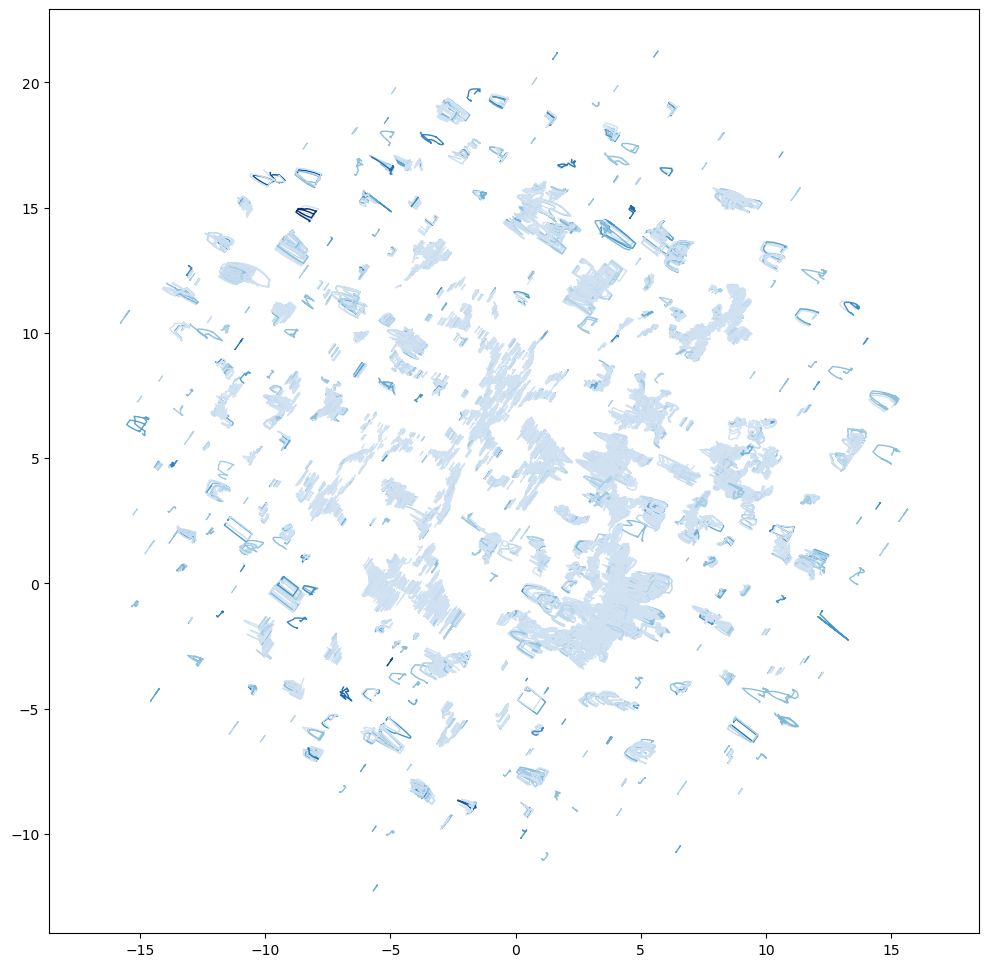

In [96]:
centers, knn = self.show_glyph_embedding(spacing=.0125, glyph_size=100, show_labels=False);

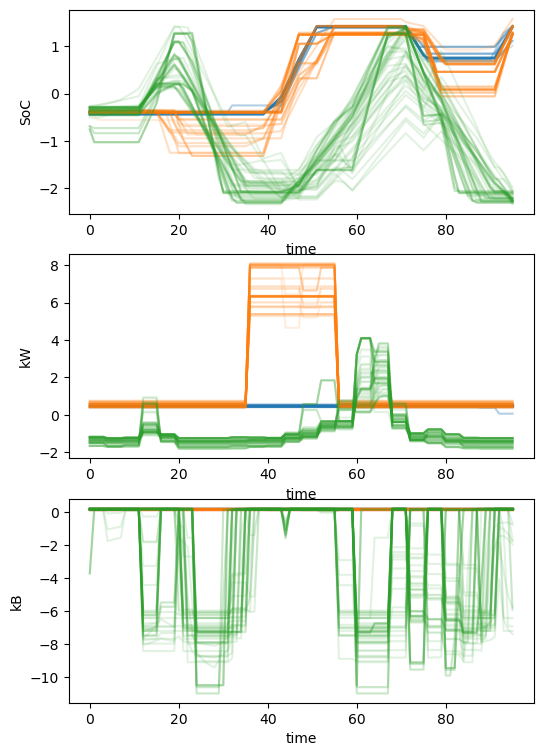

In [91]:
clusters = [4097, 3821, 7941]
self.show_raw(
    self.select_glyphs_from_cluster(knn, *clusters),
    names=[f'Cluster {ci}' for ci in clusters],
    combined=True
)

In [7]:
# todo: density peak clustering would work?

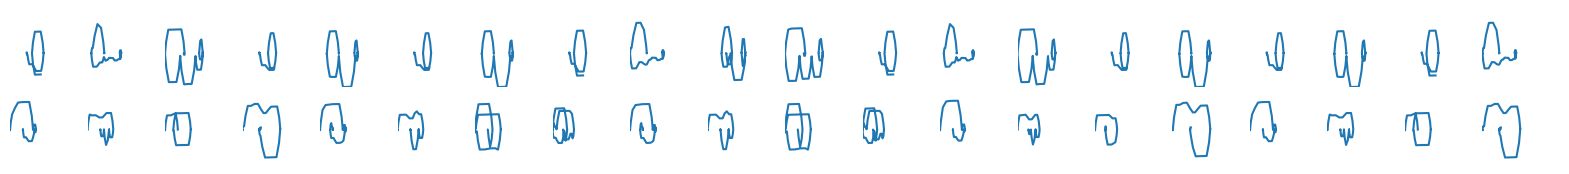

In [10]:
# todo: sample
self.show_glyphs(
    self.select_glyphs_from_cluster(knn, *clusters),
    # rescale='none'
    # combined=True, # todo: combine glyphs
)

In [79]:
df_config

,duration,power,technology,location,capacity,cost,size,cable,objective
config,,,,,,,,,
control_solution_c4_p1000_LFP_MOSSLAND,4,1000,LFP,MOSSLAND,1800.0,1406.11,44.819999,1629.705002,2932.687641
control_solution_c8_p1000_VRF_COTTONWOOD,8,1000,VRF,COTTONWOOD,1810.0,3652.63,0.000006,1618.102297,3470.498010
control_solution_c2_p100_LAB_JOHNDAY,2,100,LAB,JOHNDAY,2350.0,957.58,58.514999,2127.670419,4792.285652
control_solution_c4_p100_LFP_WCASCADE,4,100,LFP,WCASCADE,1500.0,1490.89,37.349999,1358.087501,2692.958225
control_solution_c6_p1000_VRF_JOHNDAY,6,1000,VRF,JOHNDAY,2350.0,3248.67,0.000034,2100.851060,4748.688494
...,...,...,...,...,...,...,...,...,...
control_solution_c4_p1000_LFP_JOHNDAY,4,1000,LFP,JOHNDAY,2350.0,1406.11,58.514999,2127.670419,4784.660727
control_solution_c8_p100_NMC_TESLA,8,100,NMC,TESLA,2640.0,3141.71,1.186058,2360.648613,4995.617342
control_solution_c4_p100_LFP_COTTONWOOD,4,100,LFP,COTTONWOOD,1810.0,1490.89,45.068999,1638.758919,3494.801517


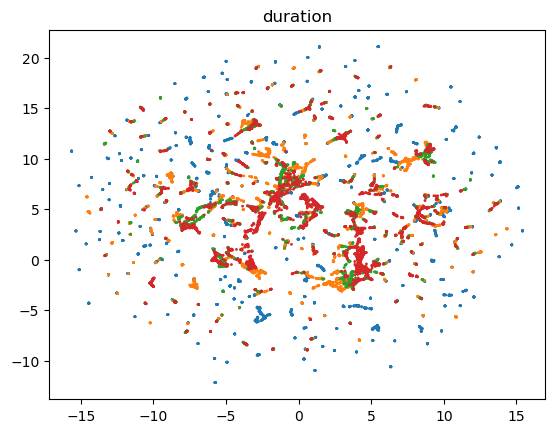

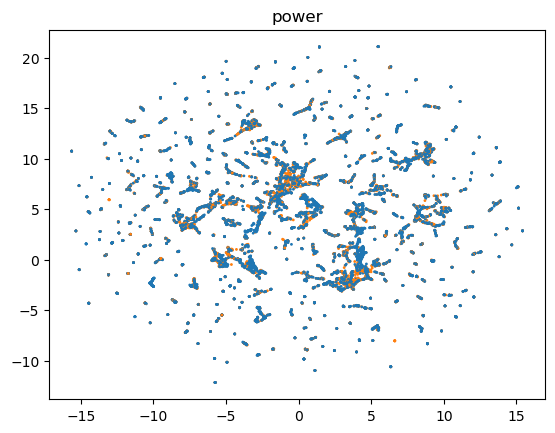

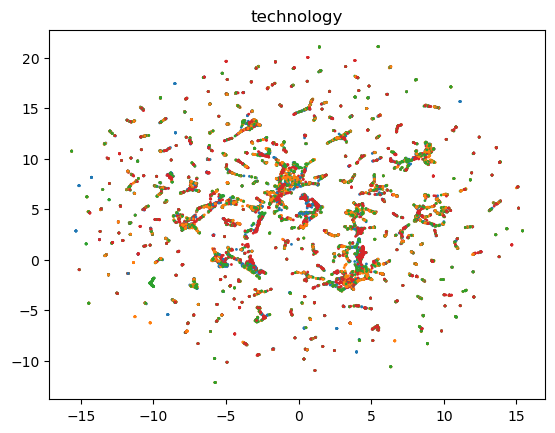

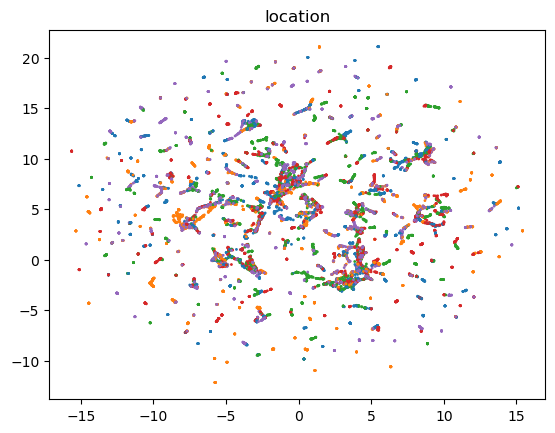

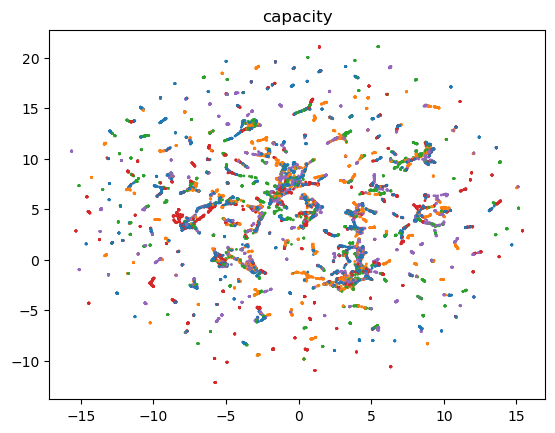

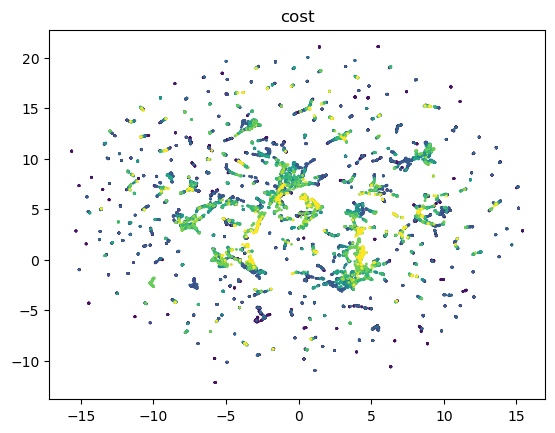

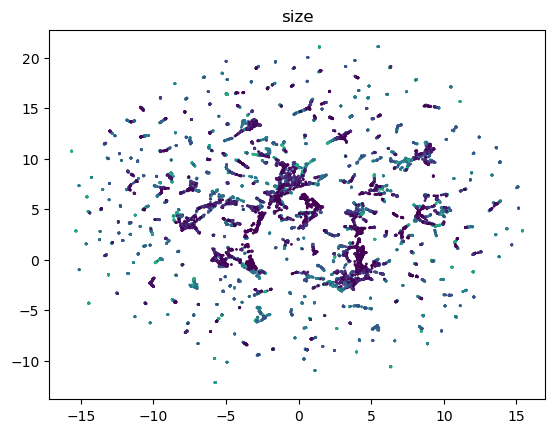

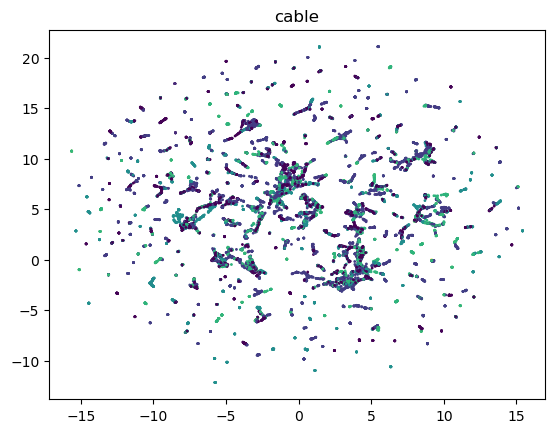

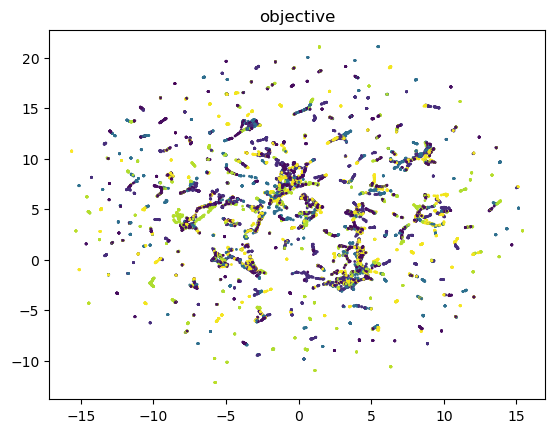

In [88]:
for c in df_config:
    color = df_config.loc[self.X.index.get_level_values(0), c]
    cmap = plt.cm.viridis
    vmax=None

    if len(set(color)) <= 10:
        _, color = np.unique(color, return_inverse=True)
        cmap = plt.cm.tab10
        vmax = 9
        

    plt.figure()
    plt.scatter(*self.xy.T, s=1, c=color, cmap=cmap, vmax=vmax)
    plt.title(c)
